In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import rc
import matplotlib as mpl

# Set `usetex=False' if you do not have LaTeX installed.
rc('text', usetex=True)
rc('font', family='serif')
mpl.rcParams['text.latex.preamble'] = [r"\usepackage{amsmath}"]

In [2]:
rcParams["mathtext.fontset"] = "stix"
# rcParams["font.family"] = "Liberation serif"
rcParams["font.size"] = "25"
# rcParams['font.weight']='bold'
rcParams["figure.figsize"] = "8.0, 8.0"
rcParams["figure.autolayout"] = "False"

rcParams["axes.linewidth"] = "1.7"
rcParams["axes.labelpad"] = "15.0"
rcParams["axes.titlepad"] = "15.0"

rcParams["xtick.direction"] = "in"
rcParams["xtick.top"] = True
rcParams["xtick.major.pad"] = "10.0"
rcParams["xtick.minor.pad"] = "10.0"
rcParams["xtick.major.size"] = "10.0"
rcParams["xtick.major.width"] = "1.7"
rcParams["xtick.minor.size"] = "5.0"
rcParams["xtick.minor.width"] = "1.7"
rcParams["xtick.labelsize"] = "25"

rcParams["ytick.direction"] = "in"
rcParams["ytick.right"] = True
rcParams["ytick.major.pad"] = "10.0"
rcParams["ytick.minor.pad"] = "10.0"
rcParams["ytick.major.size"] = "10.0"
rcParams["ytick.major.width"] = "1.7"
rcParams["ytick.minor.size"] = "5.0"
rcParams["ytick.minor.width"] = "1.7"
rcParams["ytick.labelsize"] = "25"

In [3]:
data = pd.read_csv("../data/initial_population.txt")
data.head()

,age,r_initial,phi_initial,x_initial,y_initial,z_initial,v_r_initial,v_phi_initial,v_z_initial,vp_r,vp_phi,vp_z,v_orb
0,[yr],[kpc],[rad],[kpc],[kpc],[kpc],[kpc / yr],[kpc /yr],[kpc / yr],[kpc / yr],[kpc /yr],[kpc / yr],[kpc / yr]
1,15985590.664174812,14.363853211761853,11.52456657687954,7.2489142274902685,-12.400545214285156,0.038955567057509174,1.1251772334222456e-08,-2.0022193127978008e-07,-2.2296218742896768e-07,1.1251772334222456e-08,3.772391837262095e-09,-2.2296218742896768e-07,-2.0399432311704217e-07
2,92147356.96312477,6.66300691816334,8.587626639967617,-4.461425261395935,4.948873187754032,-0.023019451798213957,8.049256476090668e-07,-3.235510530504574e-07,1.7326224464192767e-06,8.049256476090668e-07,-9.507970515572254e-08,1.7326224464192767e-06,-2.2847134789473487e-07
3,52264041.55899527,9.590832841485442,9.00952709375605,-8.775757299727111,3.8691288954494696,-0.06501879509124103,2.8644359014666905e-08,-3.6036058100508137e-07,3.426443359097757e-07,2.8644359014666905e-08,-1.3671113718064212e-07,3.426443359097757e-07,-2.2364944382443928e-07
4,71656019.94055623,2.4427282617197967,3.2840078700642987,-2.4179982801574345,-0.3467069046908483,0.10354590362155669,-7.297514171951458e-07,2.464995042111024e-08,-1.038511696799255e-06,-7.297514171951458e-07,2.3002325248235854e-07,-1.038511696799255e-06,-2.053733020612483e-07


In [4]:
data = data[1:]
data.head()

,age,r_initial,phi_initial,x_initial,y_initial,z_initial,v_r_initial,v_phi_initial,v_z_initial,vp_r,vp_phi,vp_z,v_orb
1,15985590.664174812,14.363853211761853,11.52456657687954,7.2489142274902685,-12.400545214285156,0.038955567057509174,1.1251772334222456e-08,-2.0022193127978008e-07,-2.2296218742896768e-07,1.1251772334222456e-08,3.772391837262095e-09,-2.2296218742896768e-07,-2.0399432311704217e-07
2,92147356.96312477,6.66300691816334,8.587626639967617,-4.461425261395935,4.948873187754032,-0.023019451798213957,8.049256476090668e-07,-3.235510530504574e-07,1.7326224464192767e-06,8.049256476090668e-07,-9.507970515572254e-08,1.7326224464192767e-06,-2.2847134789473487e-07
3,52264041.55899527,9.590832841485442,9.00952709375605,-8.775757299727111,3.8691288954494696,-0.06501879509124103,2.8644359014666905e-08,-3.6036058100508137e-07,3.426443359097757e-07,2.8644359014666905e-08,-1.3671113718064212e-07,3.426443359097757e-07,-2.2364944382443928e-07
4,71656019.94055623,2.4427282617197967,3.2840078700642987,-2.4179982801574345,-0.3467069046908483,0.10354590362155669,-7.297514171951458e-07,2.464995042111024e-08,-1.038511696799255e-06,-7.297514171951458e-07,2.3002325248235854e-07,-1.038511696799255e-06,-2.053733020612483e-07
5,54609089.66290542,3.0311542828690694,3.966340220569535,-2.057372836083806,-2.2260083782187294,0.0848795665713944,-1.1825574696397648e-07,-5.236012630779272e-07,6.481029369834813e-08,-1.1825574696397648e-07,-3.148863151911888e-07,6.481029369834813e-08,-2.0871494788673838e-07


In [5]:
r_initial = pd.to_numeric(data["r_initial"]).values
x_initial = pd.to_numeric(data["x_initial"]).values
y_initial = pd.to_numeric(data["y_initial"]).values
z_initial = pd.to_numeric(data["z_initial"]).values
vp_r = pd.to_numeric(data["vp_r"]).values
vp_phi = pd.to_numeric(data["vp_phi"]).values
vp_z = pd.to_numeric(data["vp_z"]).values
v_orb = pd.to_numeric(data["v_orb"]).values

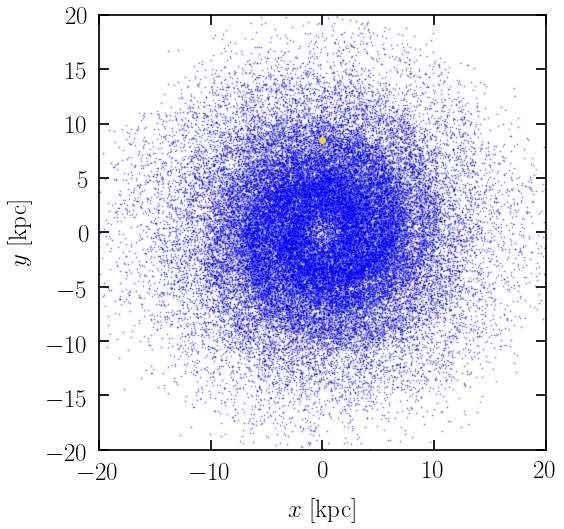

In [6]:
fig, ax = plt.subplots()

ax.plot(
    x_initial,
    y_initial,
    linestyle="None",
    marker="o",
    color="blue",
    markersize=1,
    alpha=0.3,
    rasterized=False
)

ax.plot(0.0, 8.5, marker="o", color="gold", markersize=6)
ax.set_xlabel(r"$x$ [kpc]")
ax.set_ylabel(r"$y$ [kpc]")
ax.set_xlim(-20.0, 20.0)
ax.set_ylim(-20.0, 20.0)

plt.show()

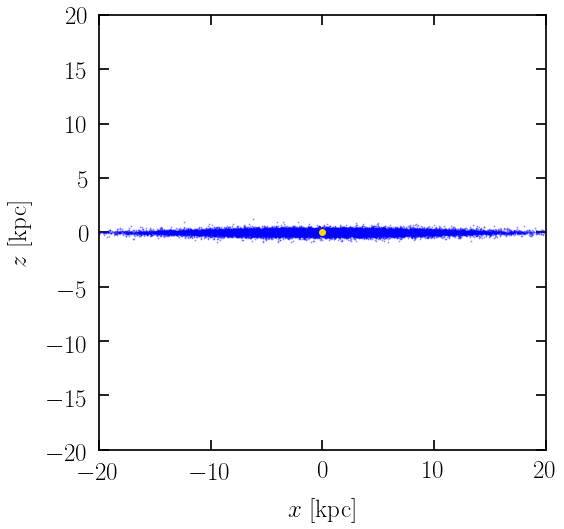

In [7]:
fig, ax = plt.subplots()

ax.plot(
    x_initial,
    z_initial,
    linestyle="None",
    marker="o",
    color="blue",
    markersize=1,
    alpha=0.3,
    rasterized=True,
)

ax.plot(0.0, 0.02, marker="o", color="gold", markersize=6)
ax.set_xlabel(r"$x$ [kpc]")
ax.set_ylabel(r"$z$ [kpc]")
ax.set_xlim(-20.0, 20.0)
ax.set_ylim(-20.0, 20.0)

plt.show()

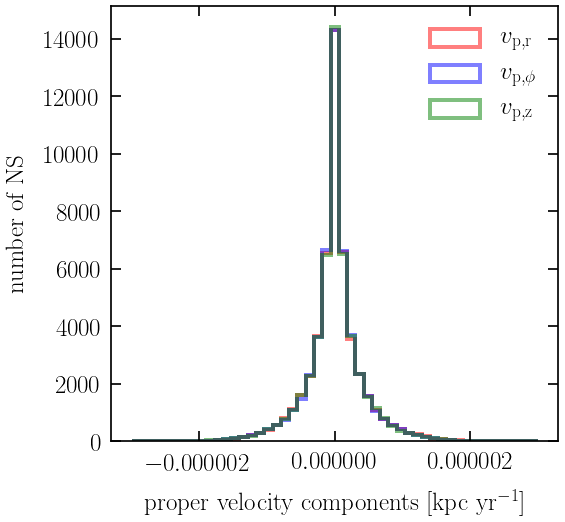

In [8]:
fig, ax = plt.subplots()
#x_bins = np.linspace(-2000.,2000.,50)  # bins for velocity in km / s
x_bins = np.linspace(-3.e-6,3.e-6,50)

ax.hist(vp_r, bins=x_bins,histtype='step',edgecolor='red',lw=4,alpha=0.5,label=r'$v_{\rm{p,}r}$')
ax.hist(vp_phi, bins=x_bins,histtype='step',edgecolor='blue',lw=4,alpha=0.5,label=r'$v_{\rm{p,}\phi}$')
ax.hist(vp_z, bins=x_bins,histtype='step',edgecolor='green',lw=4,alpha=0.5,label=r'$v_{\rm{p,}z}$')
ax.set_xlabel(r'proper velocity components [kpc yr$^{-1}$]')
ax.set_ylabel(r'number of NS')
plt.legend(frameon=False,loc=0)

plt.show()

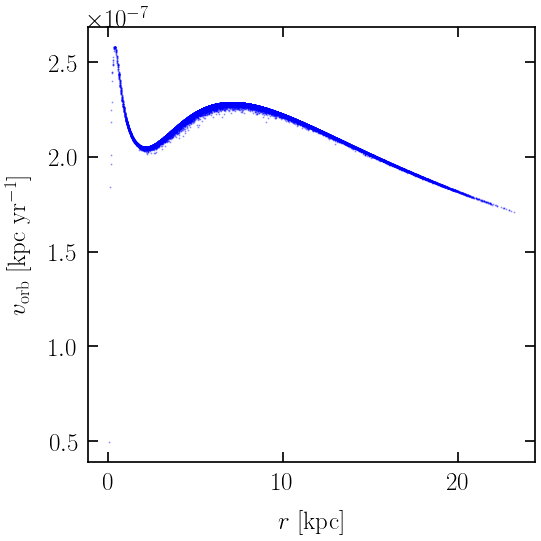

In [9]:
fig, ax = plt.subplots()

ax.plot(
    r_initial,
    abs(v_orb),
    linestyle="None",
    marker="o",
    color="blue",
    markersize=1,
    alpha=0.3,
    rasterized=True,
)

ax.set_xlabel(r"$r$ [kpc]")
ax.set_ylabel(r"$v_{\rm orb}$ [kpc yr$^{-1}$]")

plt.show()